In [3]:
from IPython.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.ticker import MultipleLocator, FormatStrFormatter
from astropy.io import fits
from astropy.wcs import WCS
from astropy import units as u
from astropy.visualization.wcsaxes import WCSAxes
#from wcsaxes import WCSAxes
import matplotlib.patches as patches
import matplotlib as mpl
font = {'size'   : 5}
mpl.rc('font', **font)
#minorLocator = MultipleLocator(10)

#import matplotlib.style
#mpl.style.use('classic')

levs = np.arange(1,16,2)
rms = np.array([ 0.00105744,  0.0011065 ,  0.00107581,  0.00106395,  0.00104511,
        0.00115306,  0.0013813 ,  0.00135966,  0.00165068,  0.00234356,
        0.00295551,  0.00279686,  0.00263257,  0.00274225,  0.00309272,
        0.00282996,  0.00337018,  0.00555825,  0.00955528,  0.01533015,
        0.02186677,  0.03132301,  0.0209814 ,  0.00771887,  0.02819715,
        0.02622415,  0.02021169,  0.01144515,  0.00706194,  0.0030581 ,
        0.00173754,  0.00142555,  0.00120538,  0.00116192,  0.00122801,
        0.00119458,  0.00116511,  0.00110102,  0.00110997,  0.00110746])

rms = 5e4

vsys = 6.86
v13=(38.525-vsys)
v14=(35.350-vsys)
v15=(32.175-vsys)
v16=(29.000-vsys)
v17=(25.825-vsys)
v18=(22.650-vsys)
v19=(19.475-vsys)
v20=(16.300-vsys)
v21=(13.125-vsys)
v22= (9.950-vsys)

xoffset=1 #4
yoffset=5 #0
spax = 8 #pixels between pol segements
spay = 8

d0 = fits.open("/Users/tching/Desktop/proposals/ALMA/Cycle4/COpolarization/python/sn3_10/data/red.pa18.fits")
h0 = d0[0].header
ps = np.around(h0['CDELT2']*3600 ,4) #pixel size in arcsec
ra0_deg = h0['CRVAL1']
dec0_deg = h0['CRVAL2']
fsx = 3. #figure size x in arcsec
fsy = fsx #15 #figure size y in arcsec
crarc1 = 0. #xoffset of plot center in arcsec
crarc2 = 3.1 #yoffset of plot center in arcsec
sx = np.round(fsx/ps) #x size
sy = np.round(fsy/ps) #y size
h0['NAXIS1'] = sx
h0['CRPIX1'] = round(sx/2) + round(crarc1/ps)
h0['NAXIS2'] = sy
h0['CRPIX2'] = round(sy/2) + round(crarc2/ps)
wcs = WCS(h0)
d0.close()

#4a1: 03 29 10.529 31 13 31.05 #from Reipurth 2002
#4a2: 03 29 10.421 31 13 32.21
ra=np.array([3,29,10.529])
dec=np.array([31,13,31.05])
dec1_deg=dec[0]+dec[1]/60+dec[2]/3600
ra1_deg=(ra[0]+ra[1]/60+ra[2]/3600)*15
dec1_pix_offset = h0['CRPIX2']+(dec1_deg-dec0_deg)*3600/ps
ra1_pix_offset = h0['CRPIX1']-(ra1_deg-ra0_deg)*3600*np.cos(dec0_deg*np.pi/180)/ps

ra=np.array([3,29,10.421])
dec=np.array([31,13,32.21])
dec2_deg=dec[0]+dec[1]/60+dec[2]/3600
ra2_deg=(ra[0]+ra[1]/60+ra[2]/3600)*15
dec2_pix_offset = h0['CRPIX2']+(dec2_deg-dec0_deg)*3600/ps
ra2_pix_offset = h0['CRPIX1']-(ra2_deg-ra0_deg)*3600*np.cos(dec0_deg*np.pi/180)/ps

d1 = fits.open("/Users/tching/Desktop/proposals/ALMA/Cycle4/COpolarization/python/sn3_10/data/red.i.cm.fits")
data1 = d1[0].data
data2 = data1.squeeze()
h = d1[0].header
naxis = h['NAXIS1']
d1.close() 

pix_min_y = int((naxis-sx)/2) - round(crarc1/ps)
pix_max_y = int(pix_min_y + sx) #naxis-pix_min_y - round(crarc1/ps)
pix_min_x = int((naxis-sy)/2) - round(crarc2/ps)
pix_max_x = int(pix_min_x + sy) #naxis-pix_min_x - round(crarc2/ps)
print(pix_min_y,pix_max_y,pix_min_x,pix_max_x)

######intensity to number density #######
AUtoCM = 1.496e13 # 1 AU = 1.496e13 cm
PCtoCM = 3.086e18 # 1 pc = 3.09e18 cm
h = 6.626e-27 #planck's constant in cm2 g s-1
k = 1.381e-16 #Boltzmann's constant in cm2 g s-2 K-1
c = 2.998e10 #light speed in cm s-1
mmw = 2.86 #mean molecular weight, (Kirk et al. 2013; Pattle et al. 2015) 
Hm = 1.674e-24 #HI mass in g

freq = 2.30538e2 #CO 2-1 freq. in GHz
bmaj = 1.36818736792e-04 * 3600 #major beam in arcsec
bmin = 9.05337437871e-05 * 3600 #minor beamin arcsec
chan_vel = 3.175 #channel velocity width in km/s
E_u = 16.59608 #upper level energy of CO 2-1 in Kelvin
Aij = 10**-6.16 #CO 2-1 A coefficient in s-1
B0 = 57635.968 #in MHz CO rotational constant https://physics.nist.gov/PhysRefData/MolSpec/Diatomic/Html/Tables/CO.html
co2H2 = 1e-4 #CO to H2 ratio, Dickman 1978
J = 2 #upper rotation level

### IAS4A outflow paras ###
dist = 300 #in pc
v0 = 4.8 #in km s-1 arcsec-1, 15.6*np.sin(18.1*np.pi/180) from pv_red_2fits1v2c1incl_6.86 
delta_vlos = 0.8 #turbulent linewidth, in km/s
Tex = 70 #in Kelvin

T1 = 1.222e3 * (data2*1000)/(freq**2*bmaj*bmin) #from Jy/beam to Kelvin
Qrot = k*Tex/(h*B0*1e6) + 1./3. #Eq 52 in Mangum & Shirley 2015
N1 = 8*np.pi*(freq*1e9)**2*k/(Aij*h*c**3)*Qrot/(2*J+1)*np.exp(E_u/Tex)*T1*(chan_vel*1e5)
#column density of total CO transitions in cm-2, Eq 82 in Mangum & Shirley 2015, Eq 1 in Goldsmith 1997
chan_z = chan_vel/v0*dist*AUtoCM #the line-of-sight depth of each channel in cm
data2 = N1/co2H2/chan_z #H2 number density in cm-3

##########

red15 = data2[15,pix_min_x:pix_max_x,pix_min_y:pix_max_y]
red16 = data2[16,pix_min_x:pix_max_x,pix_min_y:pix_max_y]
red17 = data2[17,pix_min_x:pix_max_x,pix_min_y:pix_max_y]
red18 = data2[18,pix_min_x:pix_max_x,pix_min_y:pix_max_y]
red19 = data2[19,pix_min_x:pix_max_x,pix_min_y:pix_max_y]
red20 = data2[20,pix_min_x:pix_max_x,pix_min_y:pix_max_y]
red21 = data2[21,pix_min_x:pix_max_x,pix_min_y:pix_max_y]
red22 = data2[22,pix_min_x:pix_max_x,pix_min_y:pix_max_y]
red24 = data2[24,pix_min_x:pix_max_x,pix_min_y:pix_max_y]
red25 = data2[25,pix_min_x:pix_max_x,pix_min_y:pix_max_y]
red26 = data2[26,pix_min_x:pix_max_x,pix_min_y:pix_max_y]
red27 = data2[27,pix_min_x:pix_max_x,pix_min_y:pix_max_y]
red28 = data2[28,pix_min_x:pix_max_x,pix_min_y:pix_max_y]
red29 = data2[29,pix_min_x:pix_max_x,pix_min_y:pix_max_y]
red30 = data2[30,pix_min_x:pix_max_x,pix_min_y:pix_max_y]
red31 = data2[31,pix_min_x:pix_max_x,pix_min_y:pix_max_y]
       
##### imbin data #####
d2bin = fits.open("/Users/tching/Desktop/proposals/ALMA/Cycle4/COpolarization/python_2024/sn3_3_imbin_x5y3/imbin_x5y3/red.i.imbin.fits")
h0bin = d2bin[0].header
data1 = d2bin[0].data
data2bin = data1.squeeze()
d2bin.close() 
iunbin_1 = np.repeat(data2bin, 8, axis=1)
iunbin = np.repeat(iunbin_1, 8, axis=2)
iunbin_cutoff = 5

naxis1 = h0bin['NAXIS1']
crpix1 = h0bin['CRPIX1']
naxis2 = h0bin['NAXIS2']
crpix2 = h0bin['CRPIX2']
X_bin,Y_bin = np.meshgrid( np.arange(0,naxis1,1)-crpix1+1,np.arange(0,naxis2,1)-crpix2+1) #+1 because header count from 1, but python array count from 0
r_bin = np.sqrt(X_bin**2+Y_bin**2)*8*ps

bf22 = np.load('/Users/tching/Desktop/proposals/ALMA/Cycle4/COpolarization/python_2024/sn3_3_imbin_x5y3_Gauss_uncertainty_241022/bf23.npy')
bf21 = np.load('/Users/tching/Desktop/proposals/ALMA/Cycle4/COpolarization/python_2024/sn3_3_imbin_x5y3_Gauss_uncertainty_241022/bf22.npy')
bf20 = np.load('/Users/tching/Desktop/proposals/ALMA/Cycle4/COpolarization/python_2024/sn3_3_imbin_x5y3_Gauss_uncertainty_241022/bf21.npy')
bf19 = np.load('/Users/tching/Desktop/proposals/ALMA/Cycle4/COpolarization/python_2024/sn3_3_imbin_x5y3_Gauss_uncertainty_241022/bf20.npy')
dBydx_dBxdy22 = np.load('/Users/tching/Desktop/proposals/ALMA/Cycle4/COpolarization/python_2024/sn3_3_imbin_x5y3_Gauss_uncertainty_241022/dBydx-dBxdy23.npy')
dBydx_dBxdy21 = np.load('/Users/tching/Desktop/proposals/ALMA/Cycle4/COpolarization/python_2024/sn3_3_imbin_x5y3_Gauss_uncertainty_241022/dBydx-dBxdy22.npy')
dBydx_dBxdy20 = np.load('/Users/tching/Desktop/proposals/ALMA/Cycle4/COpolarization/python_2024/sn3_3_imbin_x5y3_Gauss_uncertainty_241022/dBydx-dBxdy21.npy')
dBydx_dBxdy19 = np.load('/Users/tching/Desktop/proposals/ALMA/Cycle4/COpolarization/python_2024/sn3_3_imbin_x5y3_Gauss_uncertainty_241022/dBydx-dBxdy20.npy')

d2bin = fits.open("/Users/tching/Desktop/proposals/ALMA/Cycle4/COpolarization/python_2024/sn3_3_imbin_x5y3/imbin_x5y3/red.poli.fits")
data1 = d2bin[0].data
#data1[data1 == 0] = 'nan' 
#data1[:,r_bin > 25.3/3/2+0.05] = 'nan' 
data2bin = data1.squeeze()*1e3
d2bin.close()
pix_min_bf = int(naxis1/2-26/2)
pix_max_bf = int(naxis1/2+26/2)
data2bin[22,pix_min_bf:pix_max_bf,pix_min_bf:pix_max_bf] = bf22*(~np.isnan(dBydx_dBxdy22))
data2bin[21,pix_min_bf:pix_max_bf,pix_min_bf:pix_max_bf] = bf21*(~np.isnan(dBydx_dBxdy21))
data2bin[20,pix_min_bf:pix_max_bf,pix_min_bf:pix_max_bf] = bf20*(~np.isnan(dBydx_dBxdy20))
data2bin[19,pix_min_bf:pix_max_bf,pix_min_bf:pix_max_bf] = bf19*(~np.isnan(dBydx_dBxdy19))
#data2bin[data2bin == 0] = 'nan' 
poliunbin_1 = np.repeat(data2bin, 8, axis=1)
poliunbin = np.repeat(poliunbin_1, 8, axis=2)
#poliunbin[iunbin < iunbin_cutoff*rms] = 'nan' 

bf19 = poliunbin[19,pix_min_x-3:pix_max_x-3,pix_min_y-5:pix_max_y-5]
bf20 = poliunbin[20,pix_min_x-3:pix_max_x-3,pix_min_y-5:pix_max_y-5]
bf21 = poliunbin[21,pix_min_x-3:pix_max_x-3,pix_min_y-5:pix_max_y-5]
bf22 = poliunbin[22,pix_min_x-3:pix_max_x-3,pix_min_y-5:pix_max_y-5]

d2bin = fits.open("/Users/tching/Desktop/proposals/ALMA/Cycle4/COpolarization/python_2024/sn3_3_imbin_x5y3/imbin_x5y3/red.pa.fits")
data1 = d2bin[0].data
data1[data1 == 0] = 'nan' 
data1[:,r_bin > 25.3/3/2+0.05] = 'nan' 
data2bin = (data1.squeeze()+90)*np.pi/180
d2bin.close() 
pix_min_bf = int(naxis1/2-26/2)
pix_max_bf = int(naxis1/2+26/2)
data2bin[22,pix_min_bf:pix_max_bf,pix_min_bf:pix_max_bf] *= ~np.isnan(dBydx_dBxdy22)
data2bin[21,pix_min_bf:pix_max_bf,pix_min_bf:pix_max_bf] *= ~np.isnan(dBydx_dBxdy21)
data2bin[20,pix_min_bf:pix_max_bf,pix_min_bf:pix_max_bf] *= ~np.isnan(dBydx_dBxdy20)
data2bin[19,pix_min_bf:pix_max_bf,pix_min_bf:pix_max_bf] *= ~np.isnan(dBydx_dBxdy19)
data2bin[data2bin == 0] = 'nan' 
paunbin_1 = np.repeat(data2bin, 8, axis=1)
paunbin = np.repeat(paunbin_1, 8, axis=2)
#paunbin[iunbin < iunbin_cutoff*rms] = 'nan' 

pa19 = paunbin[19,pix_min_x-3:pix_max_x-3,pix_min_y-5:pix_max_y-5]
pa20 = paunbin[20,pix_min_x-3:pix_max_x-3,pix_min_y-5:pix_max_y-5]
pa21 = paunbin[21,pix_min_x-3:pix_max_x-3,pix_min_y-5:pix_max_y-5]
pa22 = paunbin[22,pix_min_x-3:pix_max_x-3,pix_min_y-5:pix_max_y-5]+np.pi
###########


420 480 358 418


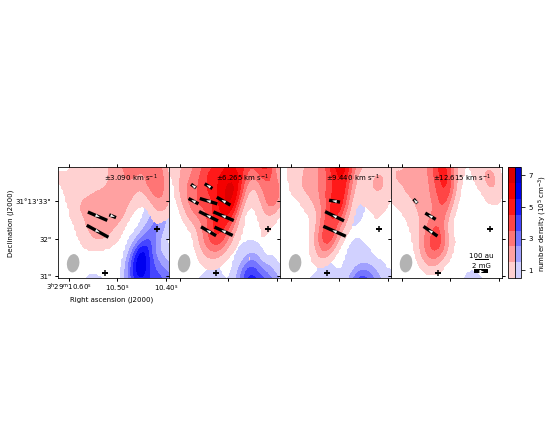

In [4]:
wd = 0.03 #0.022 #width
wd2 = 0.022 #0.022 #width
sc = 15
myheadwidth = 3.
myheadlength = 3.
myheadaxislength = 2.5

fig = plt.figure(figsize = (9,10))
fig.subplots_adjust(0.165,0.25,0.85,0.85,0,0)
myfontsize = 7
mylinewidth = 0.2
myalpha = 1.0
myvmax = np.amax(data2)*1.4
myvmin = -myvmax 

ax = fig.add_subplot(1,1,1,frameon=False)
ax.axes.get_yaxis().set_visible(False)
ax.axes.get_xaxis().set_visible(False)
ax.set_yticklabels([])
ax.set_xticklabels([])
    
X,Y = np.meshgrid( np.arange(0,sx,1),np.arange(0,sy,1) )

ax1 = fig.add_subplot(1,4,1,projection=wcs,slices=('x', 'y', 0))
lon = ax1.coords[0]
lat = ax1.coords[1]
lon.set_major_formatter('hh:mm:ss.ss')
lat.set_major_formatter('dd:mm:ss')
lon.display_minor_ticks(True)
lat.display_minor_ticks(True)
#lon.set_ticklabel_visible(False)
#lat.set_ticklabel_visible(False)
lon.set_minor_frequency(1)
lat.set_minor_frequency(1)
lon.set_ticks(number=2)
lat.set_ticks(spacing=1* u.arcsec)
lon.set_ticklabel(exclude_overlapping=True)
lat.set_ticklabel(exclude_overlapping=True)

lon.set_ticklabel(size=myfontsize)
lat.set_ticklabel(size=myfontsize)
lon.set_axislabel(' ')
lat.set_axislabel(' ')
ax1.set_aspect(1)

from matplotlib.colors import Normalize
red22[red22 < levs[0]*rms] = 0 
red24[red24 < levs[0]*rms] = 0 
ax1.contourf(red24, levels=levs*rms, cmap='seismic_r',alpha=myalpha, vmin=myvmin, vmax=myvmax)
ax1.contourf(red22, levels=levs*rms, cmap='seismic',alpha=myalpha, vmin=myvmin, vmax=myvmax)
ax1.scatter(ra2_pix_offset,dec2_pix_offset,40, c='k', marker="+") 
ax1.scatter(ra1_pix_offset,dec1_pix_offset,40, c='k', marker="+") 
ax1.add_patch(patches.Ellipse((8, 8), 0.49/ps, 0.33/ps, angle=-7.9+90, linewidth=1, fc='0.7',ec='none', zorder=2))
ax1.text(0.9, 0.9, r'$\pm$'+f"{v22:.3f}"+' km s$^{-1}$', horizontalalignment='right',verticalalignment='center',transform=ax1.transAxes,fontsize=myfontsize)
ax1.quiver(X[xoffset::spax,yoffset::spay], Y[xoffset::spax,yoffset::spay], \
           np.cos(pa22[xoffset::spax,yoffset::spay])*bf22[xoffset::spax,yoffset::spay], np.sin(pa22[xoffset::spax,yoffset::spay])*bf22[xoffset::spax,yoffset::spay],\
           scale=sc, headwidth=0, headlength=0, linewidth=0, width=wd, headaxislength=0, color='k',pivot='mid',edgecolor='w')
ax1.quiver(X[xoffset::spax,yoffset::spay], Y[xoffset::spax,yoffset::spay], \
           np.cos(pa22[xoffset::spax,yoffset::spay]), np.sin(pa22[xoffset::spax,yoffset::spay]),\
           scale=27.5, headwidth=3, headlength=3*1.618, linewidth=0.3, width=wd2, headaxislength=3*1.618, color='w',pivot='mid',edgecolor='w')

ax2 = fig.add_subplot(1,4,2,projection=wcs,slices=('x', 'y', 0))
lon = ax2.coords[0]
lat = ax2.coords[1]
lon.set_major_formatter('hh:mm:ss.ss')
lat.set_major_formatter('dd:mm:ss')
lon.display_minor_ticks(True)
lat.display_minor_ticks(True)
lon.set_ticklabel_visible(False)
lat.set_ticklabel_visible(False)
lon.set_minor_frequency(1)
lat.set_minor_frequency(1)
lon.set_ticks(number=2, exclude_overlapping=True)
lat.set_ticks(spacing=1* u.arcsec, exclude_overlapping=False)
lon.set_ticklabel(exclude_overlapping=True)
lat.set_ticklabel(exclude_overlapping=True)
lon.set_ticklabel(size=myfontsize)
lat.set_ticklabel(size=myfontsize)
lon.set_axislabel(' ')
lat.set_axislabel(' ')
ax2.set_aspect(1)
red21[red21 < levs[0]*rms] = 0 
red25[red25 < levs[0]*rms] = 0
ax2.contourf(red25, levels=levs*rms,cmap='seismic_r',alpha=myalpha, vmin=myvmin, vmax=myvmax)
ax2.contourf(red21, levels=levs*rms,cmap='seismic',alpha=myalpha, vmin=myvmin, vmax=myvmax)
ax2.set_xticklabels([])
ax2.set_yticklabels([])
ax2.scatter(ra2_pix_offset,dec2_pix_offset,40, c='k', marker="+") 
ax2.scatter(ra1_pix_offset,dec1_pix_offset,40, c='k', marker="+") 
ax2.add_patch(patches.Ellipse((8, 8), 0.49/ps, 0.33/ps, angle=-7.9+90, linewidth=1, fc='0.7',ec='none', zorder=2))
ax2.text(0.9, 0.9, r'$\pm$'+f"{v21:.3f}"+' km s$^{-1}$', horizontalalignment='right',verticalalignment='center',transform=ax2.transAxes,fontsize=myfontsize)
ax2.quiver(X[xoffset::spax,yoffset::spay], Y[xoffset::spax,yoffset::spay], \
           np.cos(pa21[xoffset::spax,yoffset::spay])*bf21[xoffset::spax,yoffset::spay], np.sin(pa21[xoffset::spax,yoffset::spay])*bf21[xoffset::spax,yoffset::spay],\
           scale=sc, headwidth=0, headlength=0, linewidth=0, width=wd, headaxislength=0, color='k',pivot='mid',edgecolor='w')
ax2.quiver(X[xoffset::spax,yoffset::spay], Y[xoffset::spax,yoffset::spay], \
           np.cos(pa21[xoffset::spax,yoffset::spay]), np.sin(pa21[xoffset::spax,yoffset::spay]),\
           scale=27.5, headwidth=3, headlength=3*1.618, linewidth=0.3, width=wd2, headaxislength=3*1.618, color='w',pivot='mid',edgecolor='w')

ax3 = fig.add_subplot(1,4,3,projection=wcs,slices=('x', 'y', 0))
lon = ax3.coords[0]
lat = ax3.coords[1]
lon.set_major_formatter('hh:mm:ss.s')
lat.set_major_formatter('dd:mm:ss')
lon.display_minor_ticks(True)
lat.display_minor_ticks(True)
lon.set_ticklabel_visible(False)
lat.set_ticklabel_visible(False)
lon.set_minor_frequency(1)
lat.set_minor_frequency(1)
lon.set_ticks(number=2)
lat.set_ticks(spacing=1* u.arcsec, exclude_overlapping=False)
lon.set_ticklabel(size=myfontsize)
lat.set_ticklabel(size=myfontsize)
lon.set_axislabel(' ')
lat.set_axislabel(' ')
ax3.set_aspect(1)
red20[red20 < levs[0]*rms] = 0 
red26[red26 < levs[0]*rms] = 0 
ax3.contourf(red26, levels=levs*rms,cmap='seismic_r',alpha=myalpha, vmin=myvmin, vmax=myvmax)
ax3.contourf(red20, levels=levs*rms,cmap='seismic',alpha=myalpha, vmin=myvmin, vmax=myvmax)
ax3.scatter(ra2_pix_offset,dec2_pix_offset,40, c='k', marker="+") 
ax3.scatter(ra1_pix_offset,dec1_pix_offset,40, c='k', marker="+") 
ax3.add_patch(patches.Ellipse((8, 8), 0.49/ps, 0.33/ps, angle=-7.9+90, linewidth=1, fc='0.7',ec='none', zorder=2))
ax3.text(0.9, 0.9, r'$\pm$'+f"{v20:.3f}"+' km s$^{-1}$', horizontalalignment='right',verticalalignment='center',transform=ax3.transAxes,fontsize=myfontsize)
ax3.quiver(X[xoffset::spax,yoffset::spay], Y[xoffset::spax,yoffset::spay], \
           np.cos(pa20[xoffset::spax,yoffset::spay])*bf20[xoffset::spax,yoffset::spay], np.sin(pa20[xoffset::spax,yoffset::spay])*bf20[xoffset::spax,yoffset::spay],\
           scale=sc, headwidth=0, headlength=0, linewidth=0, width=wd, headaxislength=0, color='k',pivot='mid',edgecolor='w')
ax3.quiver(X[xoffset::spax,yoffset::spay], Y[xoffset::spax,yoffset::spay], \
           np.cos(pa20[xoffset::spax,yoffset::spay]), np.sin(pa20[xoffset::spax,yoffset::spay]),\
           scale=27.5, headwidth=3, headlength=3*1.618, linewidth=0.3, width=wd2, headaxislength=3*1.618, color='w',pivot='mid',edgecolor='w')

ax4 = fig.add_subplot(1,4,4,projection=wcs,slices=('x', 'y', 0))
lon = ax4.coords[0]
lat = ax4.coords[1]
lon.set_major_formatter('hh:mm:ss.s')
lat.set_major_formatter('dd:mm:ss')
lon.display_minor_ticks(True)
lat.display_minor_ticks(True)
lon.set_ticklabel_visible(False)
lat.set_ticklabel_visible(False)
lon.set_minor_frequency(1)
lat.set_minor_frequency(1)
lon.set_ticks(number=2)
lat.set_ticks(spacing=1* u.arcsec, exclude_overlapping=False)
lon.set_ticklabel(size=myfontsize)
lat.set_ticklabel(size=myfontsize)
lon.set_axislabel(' ')
lat.set_axislabel(' ')
ax4.set_aspect(1)
red19[red19 < levs[0]*rms] = 0 
red27[red27 < levs[0]*rms] = 0 
cs_blue = ax4.contourf(red27, levels=levs*rms,cmap='seismic_r',alpha=myalpha, vmin=myvmin, vmax=myvmax)
cs_red = ax4.contourf(red19, levels=levs*rms,cmap='seismic',alpha=myalpha, vmin=myvmin, vmax=myvmax)
ax4.scatter(ra2_pix_offset,dec2_pix_offset,40, c='k', marker="+") 
ax4.scatter(ra1_pix_offset,dec1_pix_offset,40, c='k', marker="+") 
ax4.add_patch(patches.Ellipse((8, 8), 0.49/ps, 0.33/ps, angle=-7.9+90, linewidth=1, fc='0.7',ec='none', zorder=2))
ax4.text(0.9, 0.9, r'$\pm$'+f"{v19:.3f}"+' km s$^{-1}$', horizontalalignment='right',verticalalignment='center',transform=ax4.transAxes,fontsize=myfontsize)
ax4.quiver(X[xoffset::spax,yoffset::spay], Y[xoffset::spax,yoffset::spay], \
           np.cos(pa19[xoffset::spax,yoffset::spay])*bf19[xoffset::spax,yoffset::spay], np.sin(pa19[xoffset::spax,yoffset::spay])*bf19[xoffset::spax,yoffset::spay],\
           scale=sc, headwidth=0, headlength=0, linewidth=0, width=wd, headaxislength=0, color='k',pivot='mid',edgecolor='w')
ax4.quiver(X[xoffset::spax,yoffset::spay], Y[xoffset::spax,yoffset::spay], \
           np.cos(pa19[xoffset::spax,yoffset::spay]), np.sin(pa19[xoffset::spax,yoffset::spay]),\
           scale=27.5, headwidth=3, headlength=3*1.618, linewidth=0.3, width=wd2, headaxislength=3*1.618, color='w',pivot='mid',edgecolor='w')

ax4.plot([48+0.3373/ps/2,48-0.3373/ps/2],[10,10],linewidth=1,color='k') #0.3373" = 100 AU with a distance of 296.5 pc from Soubiran et al. 2018
ax4.text(48,12,'100 au' ,horizontalalignment='center',verticalalignment='center',color='k',fontsize=myfontsize)
ax4.text(48, 7, r'2 mG', horizontalalignment='center',verticalalignment='center',fontsize=myfontsize)
ax4.quiver(48, 4, np.cos(0)*2, np.sin(0)*2,\
           scale=sc, headwidth=0, headlength=0, linewidth=0, width=wd, headaxislength=0, color='k',pivot='mid',edgecolor='w')
ax4.quiver(48, 4, np.cos(0), np.sin(0),\
           scale=27.5, headwidth=3, headlength=3*1.618, linewidth=0.3, width=wd2, headaxislength=3*1.618, color='w',pivot='mid',edgecolor='w')

cbar_red = fig.colorbar(cs_red,cax=fig.add_axes([0.85+0.01,0.473,0.01,0.1545]),ticks=np.arange(1,10,2)*1e5)
cbar_red.ax.set_yticklabels([],size=myfontsize)
cbar_blue = fig.colorbar(cs_blue,cax=fig.add_axes([0.85+0.02,0.473,0.01,0.1545]),ticks=np.arange(1,10,2)*1e5)
cbar_blue.ax.set_yticklabels(['1','3','5','7','9'],size=myfontsize)
cbar_blue.set_label(r'number density (10$^5$ cm$^{-3}$)',size=myfontsize)

ax.text(0.12, 0.33, r'Right ascension (J2000)',horizontalalignment='center',verticalalignment='top',transform=ax.transAxes,fontsize=myfontsize)
ax.text(-0.1, 0.5, r'Declination (J2000)',horizontalalignment='right',verticalalignment='center',
        rotation='vertical',transform=ax.transAxes,fontsize=myfontsize)

plt.savefig('chapolmap_B_paerrwright.pdf',dpi=5000)
#plt.savefig('chapolmap_B_paerrwright_positiveJ.pdf',dpi=5000) #pa19, pa20, pa21, pa22 + np.pi
#plt.savefig('chapolmap_B_paerrwright2.pdf',dpi=5000) #not show white arrows
 